# CIFAR-10 Classification with Transfer Learning (ResNet-18)

Fine-tuning pretrained ResNet-18 on CIFAR-10 dataset.

**Goal**: Achieve high accuracy with reasonable training time using transfer learning.

Based on: PyTorch Transfer Learning Guide (torchvision)

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time

torch.manual_seed(42)
np.random.seed(42)

# Performance optimizations
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CIFAR10_LABELS = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Hyperparameters

In [2]:
# Hyperparameters
IMAGE_SIZE = 224  # ResNet expects 224x224 input
BATCH_SIZE = 64   # ResNet-18 is bigger, reduce batch size if OOM
NUM_CLASSES = 10
EPOCHS = 30        # Transfer learning converges fast
WARMUP_EPOCHS = 3
LEARNING_RATE = 3e-4   # Lower LR for fine-tuning
WEIGHT_DECAY = 1e-4
FREEZE_BACKBONE = False  # True = only train classifier, False = fine-tune all

print(f'Image size: {IMAGE_SIZE}×{IMAGE_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {EPOCHS}')
print(f'LR: {LEARNING_RATE}, WD: {WEIGHT_DECAY}')
print(f'Freeze backbone: {FREEZE_BACKBONE}')

Image size: 224×224
Batch size: 64
Epochs: 30
LR: 0.0003, WD: 0.0001
Freeze backbone: False


## 3. Data Loading with Augmentation

In [3]:
# CIFAR-10 mean/std (ImageNet pretrained models use different values)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

# Strong augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Resize to 224x224
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.1),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Training samples: 50000
Test samples: 10000


## 4. Load Pretrained ResNet-18

In [4]:
# Load pretrained ResNet-18
from torchvision.models import resnet18, ResNet18_Weights

# Option 1: Freeze backbone (faster, less accurate)
# Option 2: Fine-tune all layers (slower, more accurate)

def create_resnet18_model(num_classes, freeze_backbone=False):
    """Create ResNet-18 with modified classifier for CIFAR-10."""
    # Load pretrained weights
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        # Freeze all layers except the final classifier
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer for CIFAR-10 (10 classes)
    num_features = model.fc.in_features  # 512 for ResNet-18
    model.fc = nn.Linear(num_features, num_classes)

    return model

# Create model
model = create_resnet18_model(NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model: ResNet-18 (pretrained on ImageNet)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Total parameters: 11,181,642
Trainable parameters: 11,181,642
Model: ResNet-18 (pretrained on ImageNet)


## 5. Training Function

In [5]:
from torch.amp import autocast, GradScaler

def train_model(model, train_loader, test_loader, epochs, lr, weight_decay,
                warmup_epochs, device, model_name='Model'):
    """Train with AdamW + mixed precision + warmup + cosine annealing."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Mixed precision scaler
    scaler = GradScaler('cuda') if device.type == 'cuda' else None

    # Optimizer - different LR for backbone and classifier
    if FREEZE_BACKBONE:
        # Only optimize classifier
        optimizer = optim.AdamW(model.fc.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        # Different LR for pretrained backbone and new classifier
        backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n and p.requires_grad]
        classifier_params = [p for n, p in model.named_parameters() if 'fc' in n]

        param_groups = [
            {'params': backbone_params, 'lr': lr * 0.1},  # Lower LR for pretrained layers
            {'params': classifier_params, 'lr': lr}        # Higher LR for new classifier
        ]
        optimizer = optim.AdamW(param_groups, weight_decay=weight_decay)

    # LR schedule
    warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=epochs - warmup_epochs, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        start = time.time()

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad()

            if scaler:
                with autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == targets).sum().item()
            train_total += targets.size(0)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == targets).sum().item()
                val_total += targets.size(0)

        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0 or epoch == 0:
            elapsed = time.time() - start
            print(f'Epoch [{epoch+1:3d}/{epochs}] {model_name} — '
                  f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}% | '
                  f'Loss: {history["val_loss"][-1]:.3f} | '
                  f'LR: {current_lr:.6f} | Time: {elapsed:.0f}s')

    if best_state:
        model.load_state_dict(best_state)
    print(f'\nBest {model_name} Val Acc: {best_val_acc:.2f}%')

    return model, history

print('Training function ready.')

Training function ready.


## 6. Train ResNet-18

In [6]:
print('=' * 70)
print('Training ResNet-18 (Transfer Learning from ImageNet)')
print('=' * 70)

model, history = train_model(
    model, train_loader, test_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS, device=device, model_name='ResNet-18'
)

Training ResNet-18 (Transfer Learning from ImageNet)
Epoch [  1/30] ResNet-18 — Train: 55.3% | Val: 75.5% | Loss: 0.794 | LR: 0.000003 | Time: 80s
Epoch [  5/30] ResNet-18 — Train: 93.8% | Val: 94.5% | Loss: 0.163 | LR: 0.000030 | Time: 56s
Epoch [ 10/30] ResNet-18 — Train: 97.1% | Val: 95.7% | Loss: 0.145 | LR: 0.000027 | Time: 56s
Epoch [ 15/30] ResNet-18 — Train: 98.3% | Val: 96.1% | Loss: 0.151 | LR: 0.000020 | Time: 56s
Epoch [ 20/30] ResNet-18 — Train: 98.9% | Val: 96.5% | Loss: 0.144 | LR: 0.000011 | Time: 55s
Epoch [ 25/30] ResNet-18 — Train: 99.2% | Val: 96.4% | Loss: 0.143 | LR: 0.000004 | Time: 56s
Epoch [ 30/30] ResNet-18 — Train: 99.2% | Val: 96.4% | Loss: 0.140 | LR: 0.000001 | Time: 55s

Best ResNet-18 Val Acc: 96.55%


## 7. Evaluate Model

In [7]:
# Final evaluation
model.eval()
correct, total = 0, 0
all_preds, all_targets = [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())
        correct += (preds == targets.to(device)).sum().item()
        total += targets.size(0)

final_acc = 100. * correct / total
print(f'\nFinal Test Accuracy: {final_acc:.2f}%')


Final Test Accuracy: 96.55%


## 8. Confusion Matrix

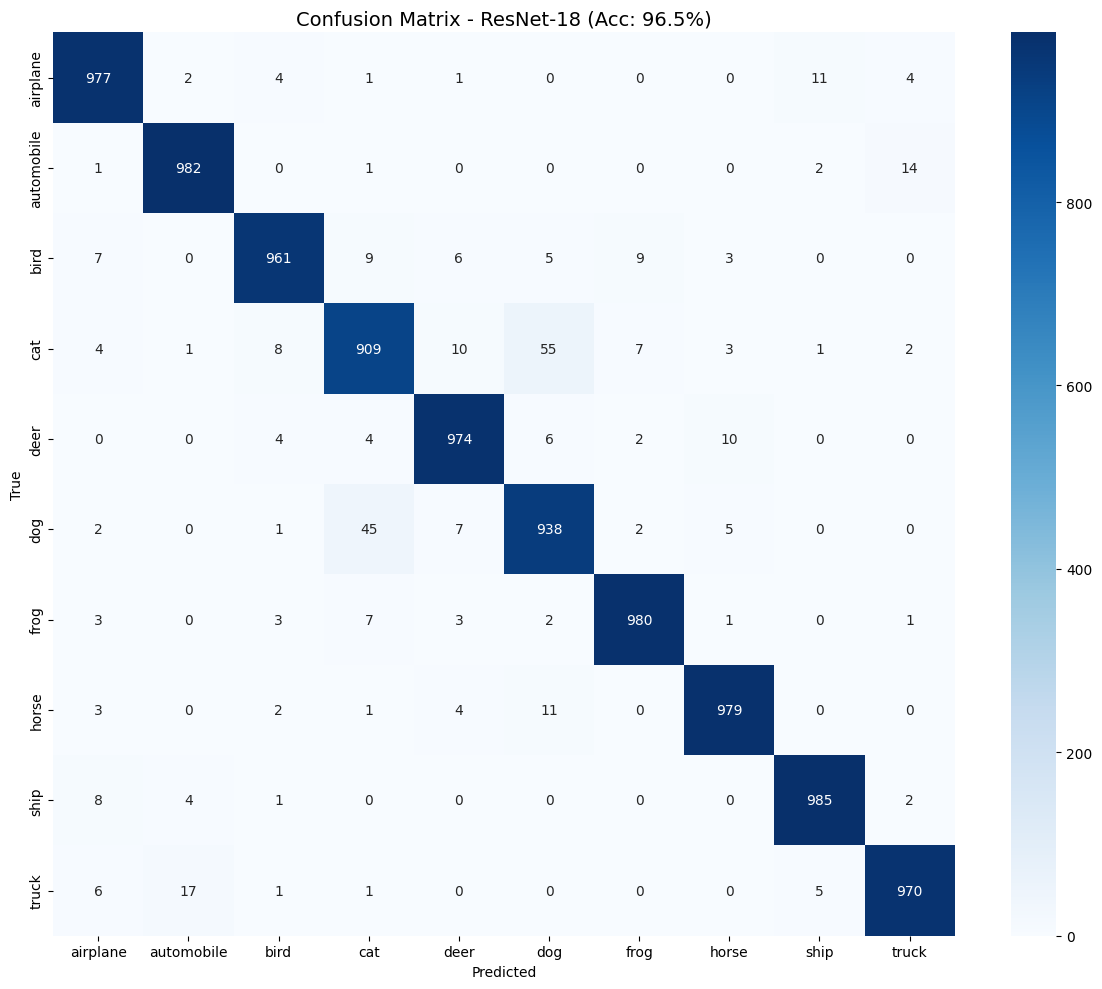


Classification Report:
              precision    recall  f1-score   support

    airplane       0.97      0.98      0.97      1000
  automobile       0.98      0.98      0.98      1000
        bird       0.98      0.96      0.97      1000
         cat       0.93      0.91      0.92      1000
        deer       0.97      0.97      0.97      1000
         dog       0.92      0.94      0.93      1000
        frog       0.98      0.98      0.98      1000
       horse       0.98      0.98      0.98      1000
        ship       0.98      0.98      0.98      1000
       truck       0.98      0.97      0.97      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [8]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_LABELS, yticklabels=CIFAR10_LABELS)
plt.title(f'Confusion Matrix - ResNet-18 (Acc: {final_acc:.1f}%)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(all_targets, all_preds, target_names=CIFAR10_LABELS))

## 9. Training Curves

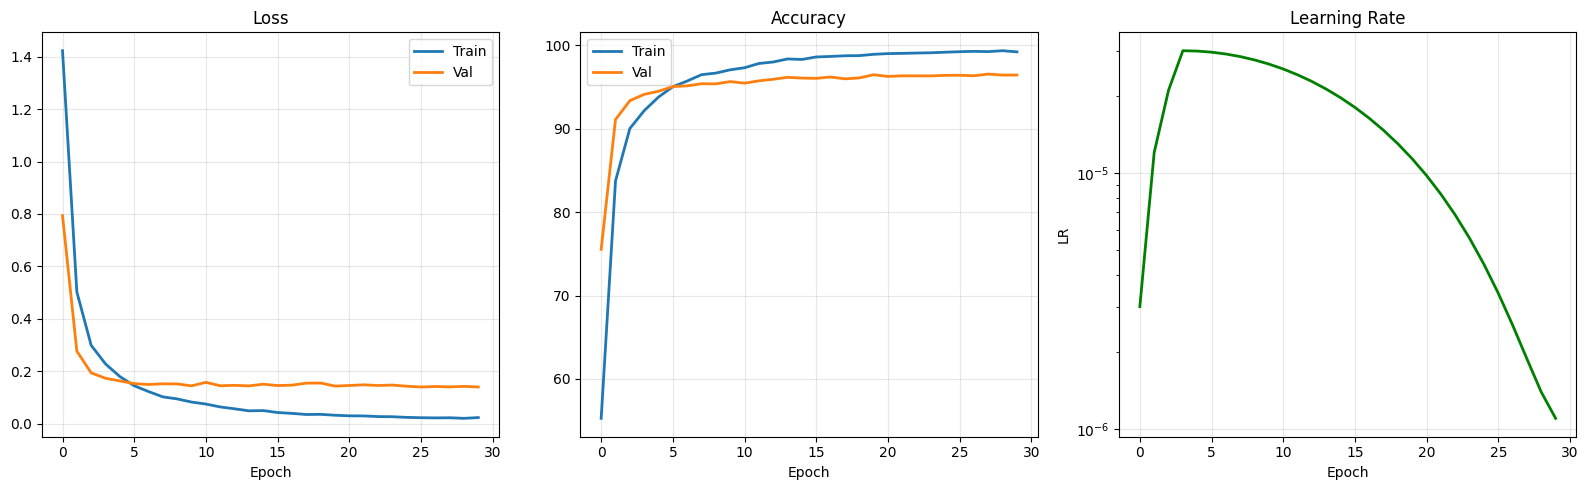

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Val', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR
axes[2].plot(history['lr'], linewidth=2, color='green')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 10. Calibration (ECE + Reliability Diagram)

This section measures **calibration quality**: whether the model's predicted confidence matches its actual correctness.

- `ECE (Expected Calibration Error)`: lower is better
- `Reliability Diagram`: compares average confidence vs. empirical accuracy in each confidence bin
- For **ViT-B/16**, running this on the **full CIFAR-10 test set** is much faster on **Colab GPU** than on local CPU


Device for calibration: cuda
Calibration samples: full test set
ECE: 0.020006
Total evaluated samples: 10000


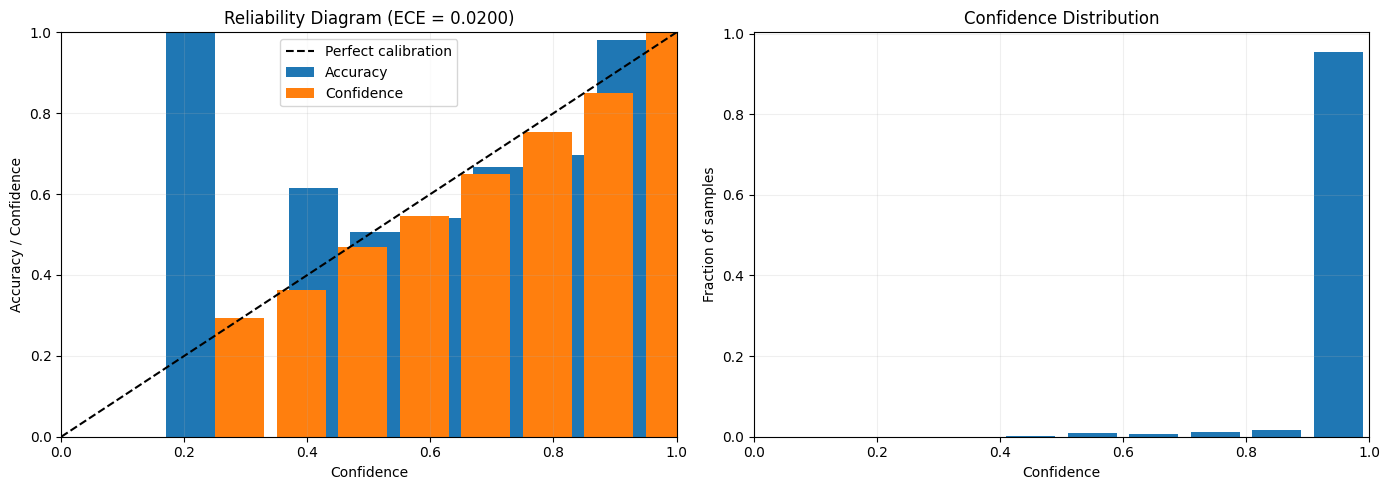

Saved figure to: ../artifacts/cnn/resnet18_calibration_full.png
Saved metrics to: ../artifacts/cnn/resnet18_calibration_metrics_full.json


In [10]:
# Calibration on the test set
# Set to None to use the full 10,000-image CIFAR-10 test split.
# If you only want a quick preview, try 500 or 1000.
from pathlib import Path
import json

CALIBRATION_MAX_SAMPLES = None
N_BINS = 10
MODEL_TAG = 'resnet18'
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def compute_calibration_metrics(model, data_loader, device, n_bins=10, max_samples=None):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    processed = 0

    with torch.inference_mode():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            targets_np = targets.numpy()

            all_probs.append(probs)
            all_preds.append(preds)
            all_targets.append(targets_np)
            processed += len(targets_np)

            if max_samples is not None and processed >= max_samples:
                break

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    if max_samples is not None:
        all_probs = all_probs[:max_samples]
        all_preds = all_preds[:max_samples]
        all_targets = all_targets[:max_samples]

    confidences = np.max(all_probs, axis=1)
    correctness = (all_preds == all_targets).astype(np.float32)
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)

    bin_accuracies = []
    bin_confidences = []
    bin_counts = []

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        if i == 0:
            mask = (confidences >= lower) & (confidences <= upper)
        else:
            mask = (confidences > lower) & (confidences <= upper)

        count = int(mask.sum())
        bin_counts.append(count)

        if count > 0:
            bin_accuracies.append(float(correctness[mask].mean()))
            bin_confidences.append(float(confidences[mask].mean()))
        else:
            bin_accuracies.append(0.0)
            bin_confidences.append(0.0)

    total = len(confidences)
    ece = sum(
        (count / total) * abs(acc - conf)
        for count, acc, conf in zip(bin_counts, bin_accuracies, bin_confidences)
    )

    return ece, bin_accuracies, bin_confidences, bin_counts


def plot_reliability_diagram(ece, bin_accuracies, bin_confidences, bin_counts, save_path=None):
    bin_centers = np.linspace(0.05, 0.95, len(bin_accuracies))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(bin_centers - 0.04, bin_accuracies, width=0.08, label='Accuracy')
    axes[0].bar(bin_centers + 0.04, bin_confidences, width=0.08, label='Confidence')
    axes[0].plot([0, 1], [0, 1], '--', color='black', linewidth=1.5, label='Perfect calibration')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Accuracy / Confidence')
    axes[0].set_title(f'Reliability Diagram (ECE = {ece:.4f})')
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].bar(bin_centers, np.array(bin_counts) / max(sum(bin_counts), 1), width=0.08)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Fraction of samples')
    axes[1].set_title('Confidence Distribution')
    axes[1].grid(alpha=0.2)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')

    plt.show()
    return fig


sample_tag = 'full' if CALIBRATION_MAX_SAMPLES is None else f'subset{CALIBRATION_MAX_SAMPLES}'
figure_path = ARTIFACT_DIR / f'{MODEL_TAG}_calibration_{sample_tag}.png'
metrics_path = ARTIFACT_DIR / f'{MODEL_TAG}_calibration_metrics_{sample_tag}.json'

print('Device for calibration:', device)
print('Calibration samples:', 'full test set' if CALIBRATION_MAX_SAMPLES is None else CALIBRATION_MAX_SAMPLES)

ece, bin_accuracies, bin_confidences, bin_counts = compute_calibration_metrics(
    model,
    test_loader,
    device,
    n_bins=N_BINS,
    max_samples=CALIBRATION_MAX_SAMPLES,
)

metrics = {
    'model_tag': MODEL_TAG,
    'sample_tag': sample_tag,
    'ece': float(ece),
    'num_bins': int(N_BINS),
    'total_evaluated_samples': int(sum(bin_counts)),
    'bin_accuracies': [float(x) for x in bin_accuracies],
    'bin_confidences': [float(x) for x in bin_confidences],
    'bin_counts': [int(x) for x in bin_counts],
}

with metrics_path.open('w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print(f'ECE: {ece:.6f}')
print(f'Total evaluated samples: {sum(bin_counts)}')
plot_reliability_diagram(ece, bin_accuracies, bin_confidences, bin_counts, save_path=figure_path)

print(f'Saved figure to: {figure_path}')
print(f'Saved metrics to: {metrics_path}')


## 11. Save Model


In [11]:
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'config': {
        'model': 'ResNet-18',
        'pretrained': 'ImageNet1K_V1',
        'image_size': IMAGE_SIZE,
        'epochs': EPOCHS,
        'lr': LEARNING_RATE,
        'freeze_backbone': FREEZE_BACKBONE,
    }
}, '../models/resnet18_cifar10.pth')

print('Model saved to ../models/resnet18_cifar10.pth')

Model saved to ../models/resnet18_cifar10.pth


## 12. Summary
